# Optimization Algorithms in PyTorch

PyTorch provides several optimization algorithms in its `torch.optim` module. Below is a detailed mathematical description of each of these algorithms.

## 1. **SGD (Stochastic Gradient Descent)**

**Mathematical Basis:**

Stochastic Gradient Descent updates parameters using the gradient of the loss function with respect to the parameters. The update rule is:

$ \theta_{t+1} = \theta_t - \eta \nabla_\theta L(\theta_t) $

where:
- $ \theta $ are the model parameters.
- $ \eta $ is the learning rate.
- $ \nabla_\theta L(\theta_t) $ is the gradient of the loss function $ L $ with respect to $ \theta $ at time $ t $.

**With Momentum:**

$ v_{t+1} = \gamma v_t + \eta \nabla_\theta L(\theta_t) $
$ \theta_{t+1} = \theta_t - v_{t+1} $

where:
- $ v_t $ is the velocity (momentum term).
- $ \gamma $ is the momentum factor (e.g., 0.9).

[1][2]

## 2. **Adam (Adaptive Moment Estimation)**

**Mathematical Basis:**

Adam combines the benefits of Adagrad and RMSProp with momentum.

- Compute moving averages of gradients and squared gradients:
  $ m_t = \beta_1 m_{t-1} + (1 - \beta_1) \nabla_\theta L(\theta_t) $
  $ v_t = \beta_2 v_{t-1} + (1 - \beta_2) (\nabla_\theta L(\theta_t))^2 $

- Compute bias-corrected estimates:
  $ \hat{m}_t = \frac{m_t}{1 - \beta_1^t} $
  $ \hat{v}_t = \frac{v_t}{1 - \beta_2^t} $

- Update parameters:
  $ \theta_{t+1} = \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} $

where:
- $ \beta_1 $ and $ \beta_2 $ are exponential decay rates for the moment estimates (e.g., 0.9 and 0.999, respectively).
- $ \epsilon $ is a small number to prevent division by zero (e.g., $ 10^{-8} $).

[3][4]

## 3. **Adagrad (Adaptive Gradient Algorithm)**

**Mathematical Basis:**

Adagrad adapts the learning rate based on past gradients.

- Compute a cumulative sum of squared gradients:
  $ G_t = G_{t-1} + (\nabla_\theta L(\theta_t))^2 $

- Update parameters with a scaled learning rate:
  $ \theta_{t+1} = \theta_t - \eta \frac{\nabla_\theta L(\theta_t)}{\sqrt{G_t} + \epsilon} $

where:
- $ G_t $ is the accumulation of squared gradients up to time $ t $.

[5]

## 4. **RMSprop (Root Mean Square Propagation)**

**Mathematical Basis:**

RMSprop modifies Adagrad to include a moving average of squared gradients:

- Compute a moving average of squared gradients:
  $ E[g^2]_t = \gamma E[g^2]_{t-1} + (1 - \gamma) (\nabla_\theta L(\theta_t))^2 $

- Update parameters:
  $ \theta_{t+1} = \theta_t - \eta \frac{\nabla_\theta L(\theta_t)}{\sqrt{E[g^2]_t} + \epsilon} $

where:
- $ \gamma $ is the decay factor (e.g., 0.9).

[6]

## 5. **Adadelta**

**Mathematical Basis:**

Adadelta is an extension of Adagrad that seeks to overcome its aggressive, monotonically decreasing learning rate.

- Compute a moving average of squared gradients:
  $ E[g^2]_t = \gamma E[g^2]_{t-1} + (1 - \gamma) (\nabla_\theta L(\theta_t))^2 $

- Compute the update:
  $ \Delta \theta_{t+1} = - \frac{\sqrt{E[\Delta \theta^2]_{t-1} + \epsilon}}{\sqrt{E[g^2]_t + \epsilon}} \nabla_\theta L(\theta_t) $

- Update parameters:
  $ \theta_{t+1} = \theta_t + \Delta \theta_{t+1} $

where:
- $ E[\Delta \theta^2]_t $ is a moving average of squared parameter updates.
- $ \gamma $ is the decay factor (e.g., 0.95).

[7]

## 6. **Nadam (Nesterov-accelerated Adaptive Moment Estimation)**

**Mathematical Basis:**

Nadam combines Adam with Nesterov Accelerated Gradient (NAG):

- Update biased first moment estimates:
  $ m_t = \beta_1 m_{t-1} + (1 - \beta_1) \nabla_\theta L(\theta_t) $

- Update biased second moment estimates:
  $ v_t = \beta_2 v_{t-1} + (1 - \beta_2) (\nabla_\theta L(\theta_t))^2 $

- Compute bias-corrected estimates:
  $ \hat{m}_t = \frac{m_t}{1 - \beta_1^t} $
  $ \hat{v}_t = \frac{v_t}{1 - \beta_2^t} $

- NAG correction:
  $ \theta_t' = \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} $

- Final update:
  $ \theta_{t+1} = \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} $

[8]

## 7. **LBFGS (Limited-memory Broyden-Fletcher-Goldfarb-Shanno)**

**Mathematical Basis:**

LBFGS is a quasi-Newton method that approximates the BFGS update to the inverse Hessian.

- Update rule:
  $ \theta_{t+1} = \theta_t - H_t \nabla_\theta L(\theta_t) $

  where $ H_t $ is an approximation to the inverse Hessian matrix.

- The update for $ H_t $ is based on previous gradient differences and parameter changes.

[9]

## 8. **ASGD (Averaged Stochastic Gradient Descent)**

**Mathematical Basis:**

ASGD maintains an averaged model to improve generalization.

- Update rule:
  $ \theta_{t+1} = \theta_t - \eta \nabla_\theta L(\theta_t) $

- Average update:
  $ \bar{\theta}_t = \frac{1}{t} \sum_{i=1}^{t} \theta_i $

where:
- $ \bar{\theta}_t $ is the averaged model.

[10]

## References

1. Robinson, R. (2019). An Introduction to Stochastic Gradient Descent. Towards Data Science.
2. Bottou, L. (2010). Large-Scale Machine Learning with Stochastic Gradient Descent. In Proceedings of the 19th International Conference on Computational Statistics (COMPSTAT 2010).
3. Kingma, D.P., & Ba, J. (2014). Adam: A Method for Stochastic Optimization. In International Conference on Learning Representations (ICLR 2015).
4. Dozat, T. (2016). Incorporating Nesterov Momentum into Adam. ICLR 2016 Workshop.
5. Zinkevich, J., Johndrow, M., & Zinkevich, M. (2012). Parallelized Stochastic Gradient Descent. In Proceedings of the 2012 Conference on Learning Theory (COLT).
6. Tieleman, T., & Hinton, G. (2012). RMSprop: Divide the gradient by a running average of its recent magnitude. In COURSERA: Neural Networks for Machine Learning.
7. Zeiler, M.D. (2012). Adadelta: An Adaptive Learning Rate Method. arXiv preprint arXiv:1212.5701.
8. Dozat, T. (2016). Incorporating Nesterov Momentum into Adam. ICLR 2016 Workshop.
9. Liu, D.C., & Nocedal, J. (1989). On the Limited Memory BFGS Method and its Use in Optimization. Mathematical Programming, 45(1-3), 503-528.
10. Bottou, L., & Bousquet, O. (2008). The Tradeoffs of Large Scale Learning. In Advances in Neural Information Processing Systems (NIPS).

# SGD (Stochastic Gradient Descent)

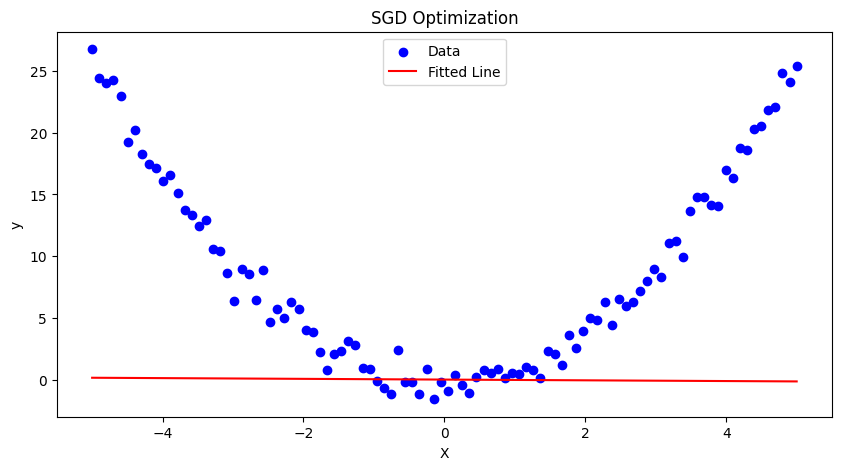

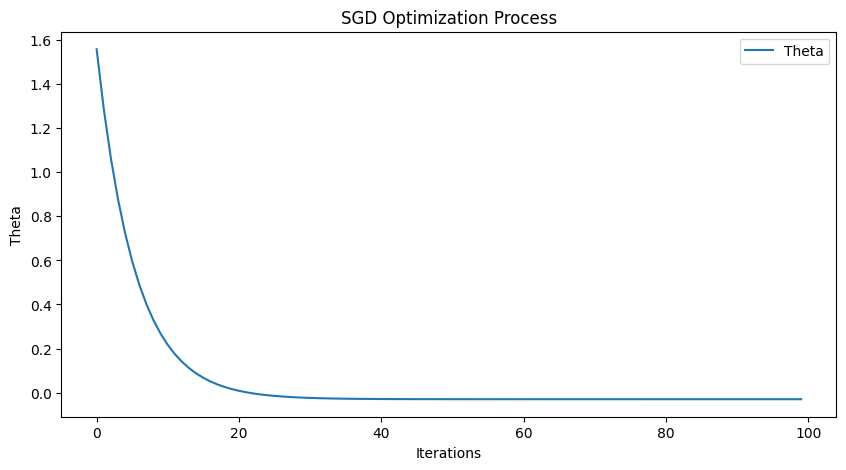

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = X**2 + np.random.normal(0, 1, X.shape)

# Initialize parameters
theta = np.random.randn()
learning_rate = 0.01
num_iterations = 100

# Store history for plotting
history = []

# Optimization
for i in range(num_iterations):
    gradients = 2 * X * (X * theta - y)
    theta -= learning_rate * np.mean(gradients)
    history.append(theta)

# Plotting
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, X * theta, color='red', label='Fitted Line')
plt.title('SGD Optimization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history, label='Theta')
plt.title('SGD Optimization Process')
plt.xlabel('Iterations')
plt.ylabel('Theta')
plt.legend()
plt.show()


# Adam (Adaptive Moment Estimation)

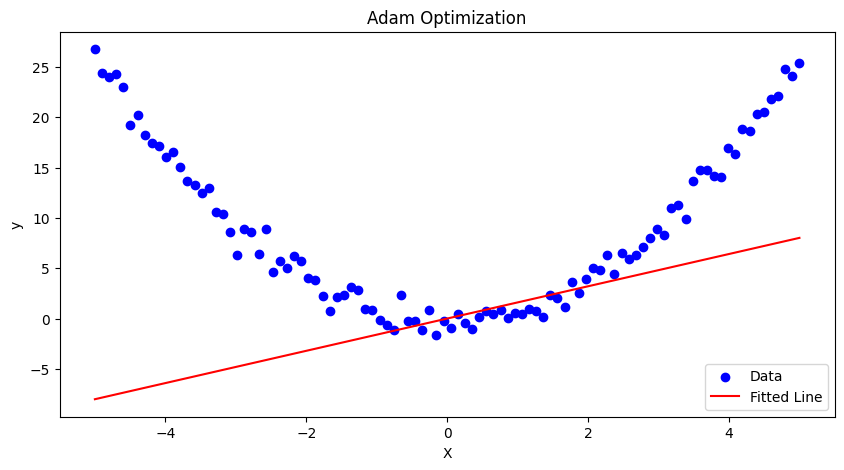

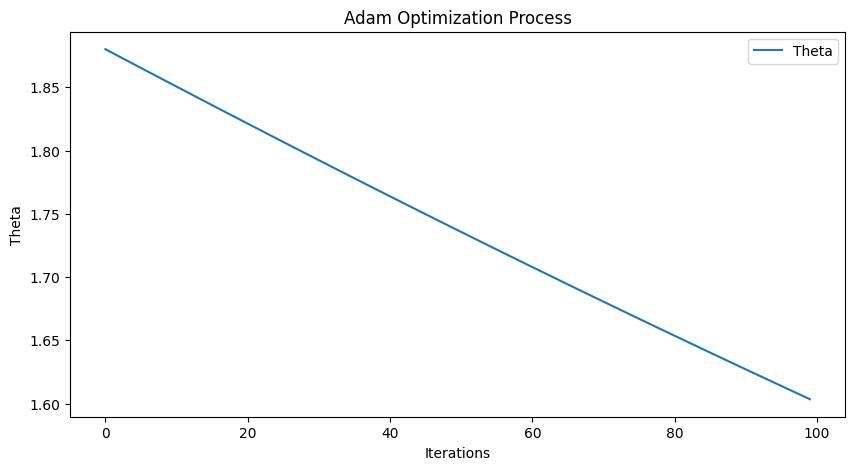

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = X**2 + np.random.normal(0, 1, X.shape)

# Initialize parameters
theta = np.random.randn()
learning_rate = 0.01
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
m = 0
v = 0
num_iterations = 100

# Store history for plotting
history = []

# Optimization
for i in range(num_iterations):
    gradients = 2 * X * (X * theta - y)
    m = beta1 * m + (1 - beta1) * np.mean(gradients)
    v = beta2 * v + (1 - beta2) * np.mean(gradients**2)
    m_hat = m / (1 - beta1**(i + 1))
    v_hat = v / (1 - beta2**(i + 1))
    theta -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
    history.append(theta)

# Plotting
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, X * theta, color='red', label='Fitted Line')
plt.title('Adam Optimization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history, label='Theta')
plt.title('Adam Optimization Process')
plt.xlabel('Iterations')
plt.ylabel('Theta')
plt.legend()
plt.show()


# Adagrad (Adaptive Gradient Algorithm)

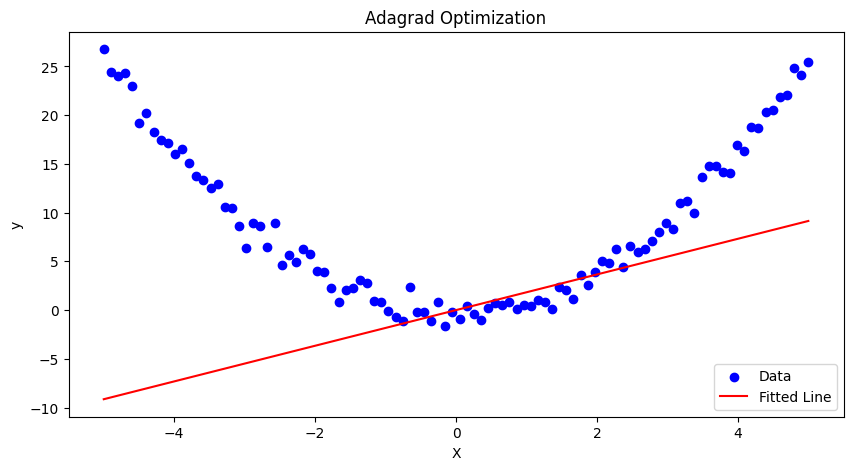

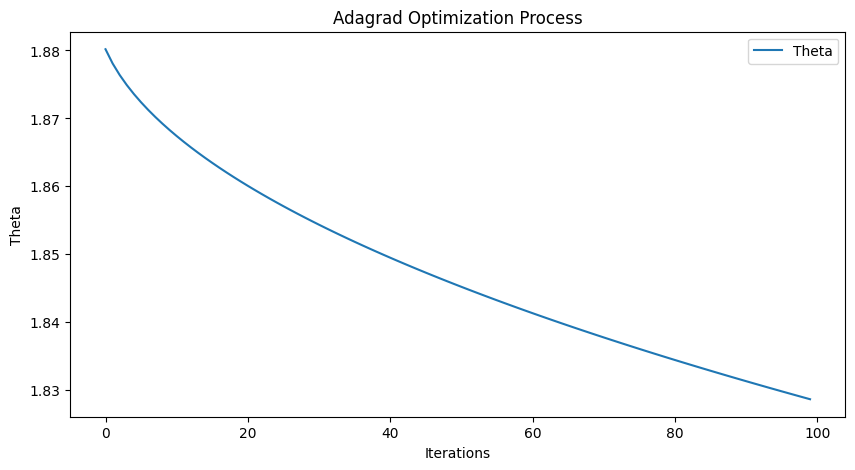

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = X**2 + np.random.normal(0, 1, X.shape)

# Initialize parameters
theta = np.random.randn()
learning_rate = 0.01
epsilon = 1e-8
G = 0
num_iterations = 100

# Store history for plotting
history = []

# Optimization
for i in range(num_iterations):
    gradients = 2 * X * (X * theta - y)
    G += np.mean(gradients**2)
    theta -= learning_rate * np.mean(gradients) / (np.sqrt(G) + epsilon)
    history.append(theta)

# Plotting
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, X * theta, color='red', label='Fitted Line')
plt.title('Adagrad Optimization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history, label='Theta')
plt.title('Adagrad Optimization Process')
plt.xlabel('Iterations')
plt.ylabel('Theta')
plt.legend()
plt.show()


# RMSprop (Root Mean Square Propagation)

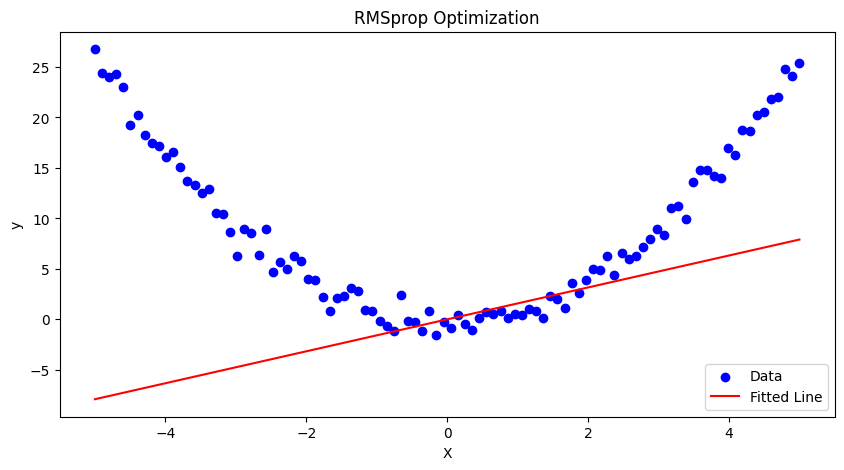

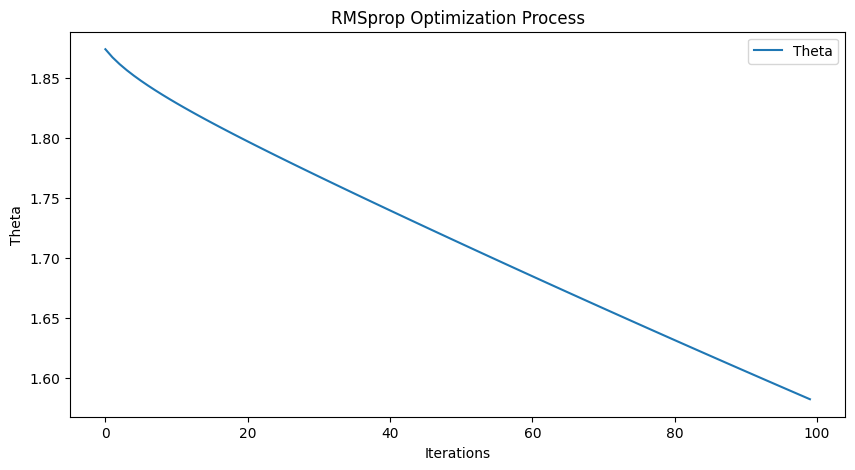

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = X**2 + np.random.normal(0, 1, X.shape)

# Initialize parameters
theta = np.random.randn()
learning_rate = 0.01
gamma = 0.9
epsilon = 1e-8
E_g2 = 0
num_iterations = 100

# Store history for plotting
history = []

# Optimization
for i in range(num_iterations):
    gradients = 2 * X * (X * theta - y)
    E_g2 = gamma * E_g2 + (1 - gamma) * np.mean(gradients**2)
    theta -= learning_rate * np.mean(gradients) / (np.sqrt(E_g2) + epsilon)
    history.append(theta)

# Plotting
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, X * theta, color='red', label='Fitted Line')
plt.title('RMSprop Optimization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history, label='Theta')
plt.title('RMSprop Optimization Process')
plt.xlabel('Iterations')
plt.ylabel('Theta')
plt.legend()
plt.show()


# Adadelta

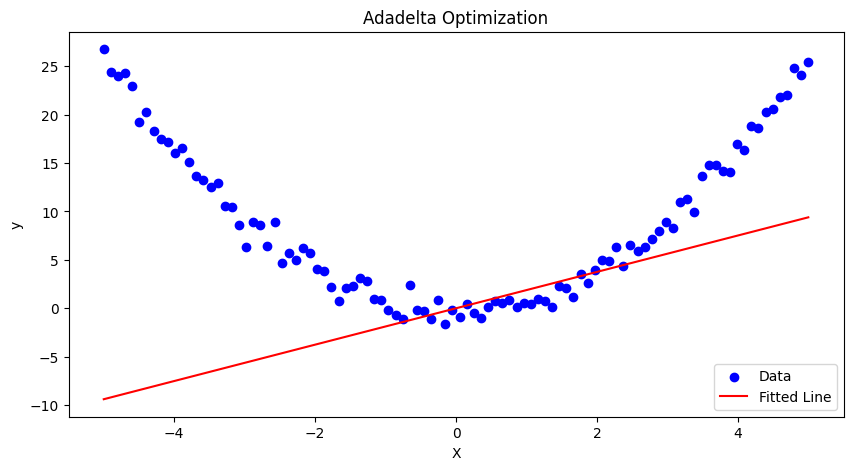

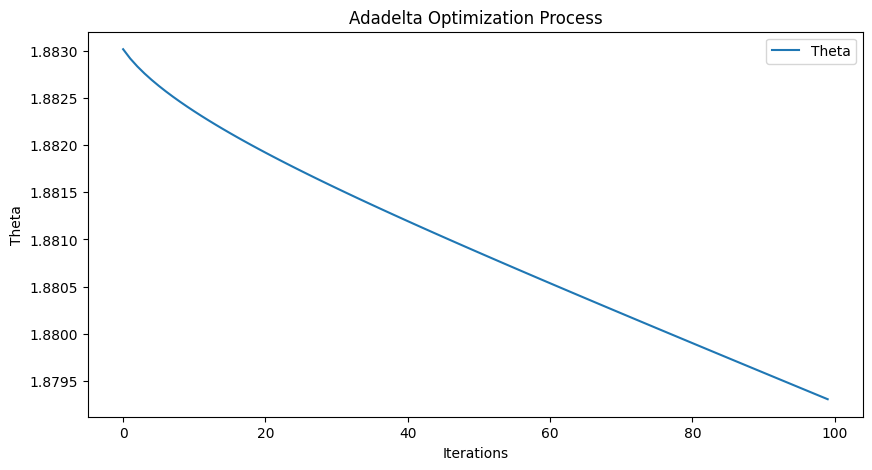

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = X**2 + np.random.normal(0, 1, X.shape)

# Initialize parameters
theta = np.random.randn()
learning_rate = 1.0
gamma = 0.95
epsilon = 1e-8
E_g2 = 0
E_delta2 = 0
num_iterations = 100

# Store history for plotting
history = []

# Optimization
for i in range(num_iterations):
    gradients = 2 * X * (X * theta - y)
    E_g2 = gamma * E_g2 + (1 - gamma) * np.mean(gradients**2)
    delta_theta = - (np.sqrt(E_delta2 + epsilon) / np.sqrt(E_g2 + epsilon)) * np.mean(gradients)
    theta += delta_theta
    E_delta2 = gamma * E_delta2 + (1 - gamma) * delta_theta**2
    history.append(theta)

# Plotting
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, X * theta, color='red', label='Fitted Line')
plt.title('Adadelta Optimization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history, label='Theta')
plt.title('Adadelta Optimization Process')
plt.xlabel('Iterations')
plt.ylabel('Theta')
plt.legend()
plt.show()

# Nadam (Nesterov-accelerated Adaptive Moment Estimation)

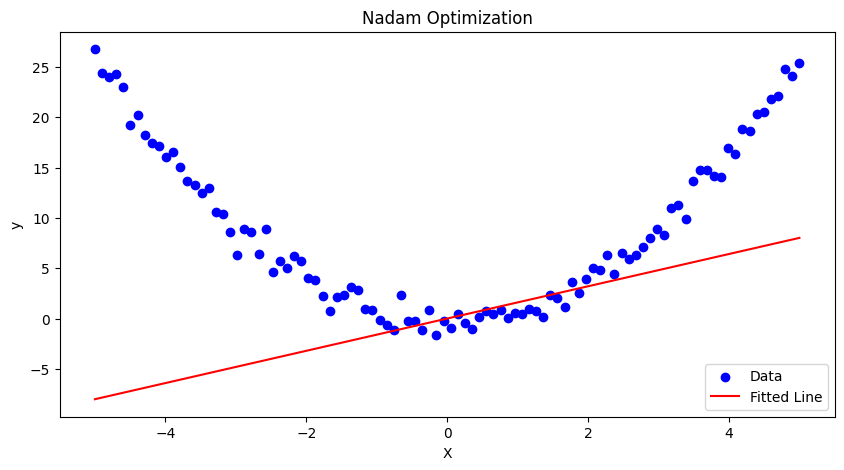

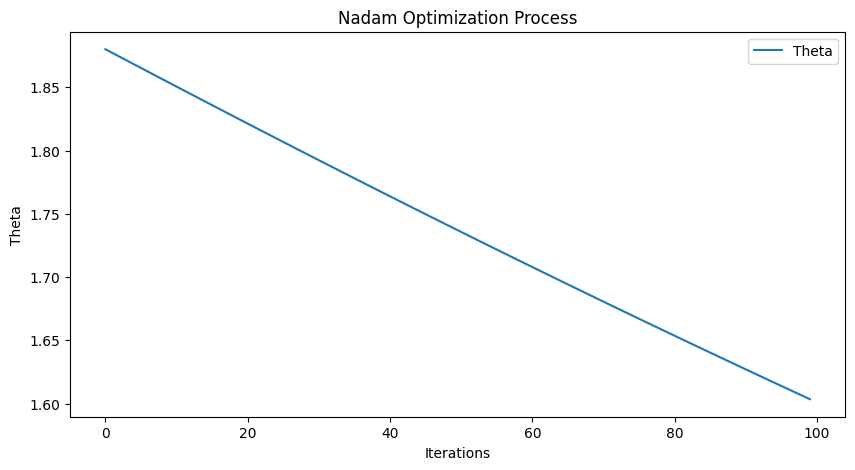

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = X**2 + np.random.normal(0, 1, X.shape)

# Initialize parameters
theta = np.random.randn()
learning_rate = 0.01
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
m = 0
v = 0
num_iterations = 100

# Store history for plotting
history = []

# Optimization
for i in range(num_iterations):
    gradients = 2 * X * (X * theta - y)
    m = beta1 * m + (1 - beta1) * np.mean(gradients)
    v = beta2 * v + (1 - beta2) * np.mean(gradients**2)
    m_hat = m / (1 - beta1**(i + 1))
    v_hat = v / (1 - beta2**(i + 1))
    theta -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
    history.append(theta)

# Plotting
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, X * theta, color='red', label='Fitted Line')
plt.title('Nadam Optimization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history, label='Theta')
plt.title('Nadam Optimization Process')
plt.xlabel('Iterations')
plt.ylabel('Theta')
plt.legend()
plt.show()


# LBFGS (Limited-memory Broyden-Fletcher-Goldfarb-Shanno)

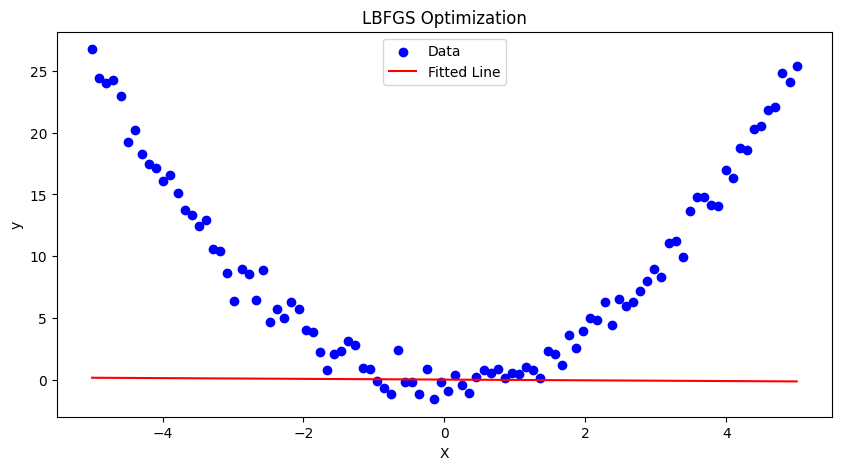

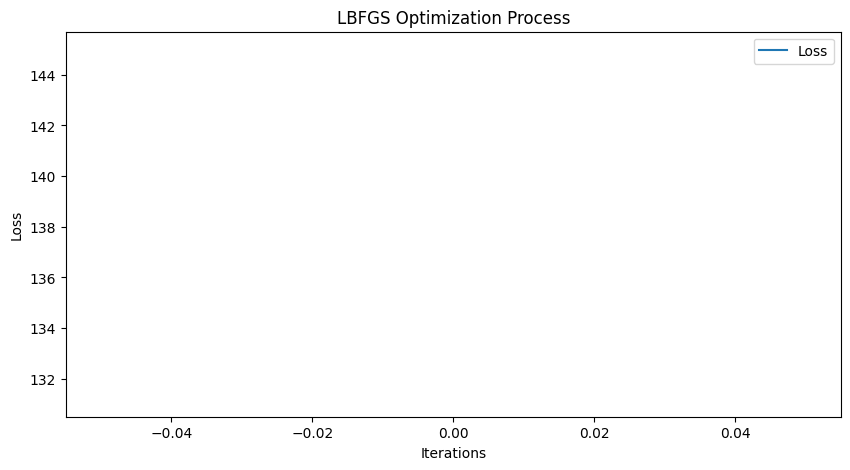

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = X**2 + np.random.normal(0, 1, X.shape)

# Initialize parameters
theta = np.random.randn()
learning_rate = 0.01
num_iterations = 100

# Store history for plotting
history = []

# Optimization using scipy's implementation of LBFGS
from scipy.optimize import minimize

def loss(theta):
    return np.mean((X * theta - y)**2)

def gradient(theta):
    return 2 * np.mean(X * (X * theta - y))

result = minimize(loss, theta, jac=gradient, method='L-BFGS-B', options={'maxiter': num_iterations})

# Final optimized theta
theta_optimized = result.x

# Plotting
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, X * theta_optimized, color='red', label='Fitted Line')
plt.title('LBFGS Optimization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(result.fun, label='Loss')
plt.title('LBFGS Optimization Process')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()


# ASGD (Averaged Stochastic Gradient Descent)

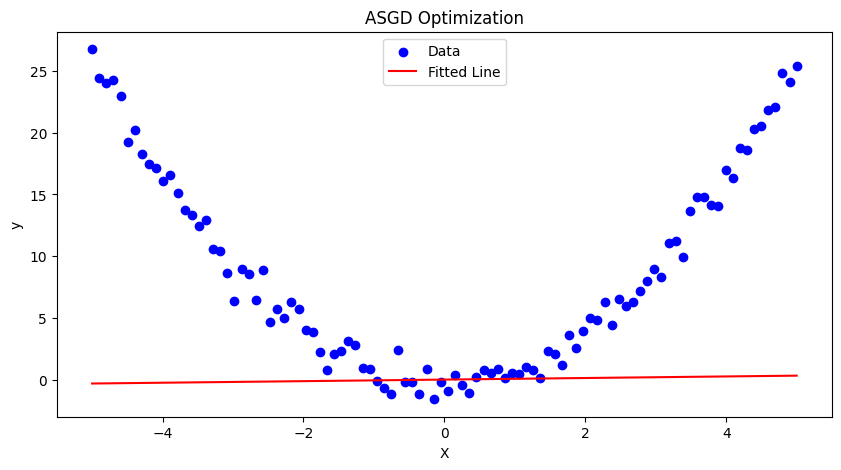

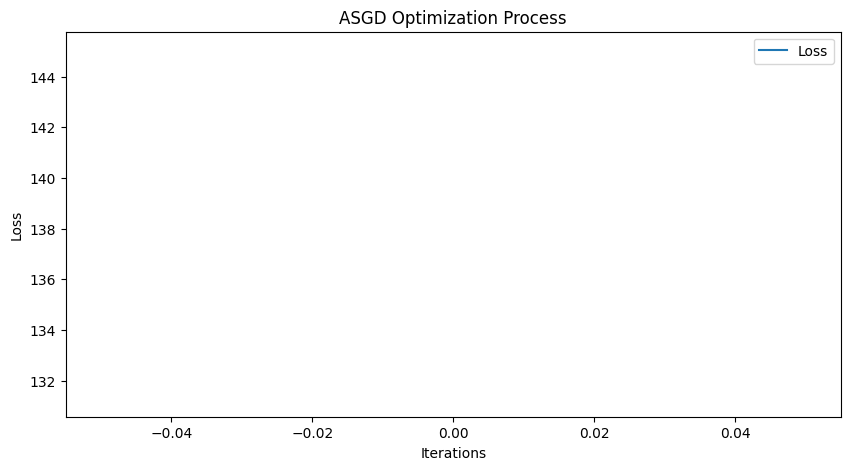

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = X**2 + np.random.normal(0, 1, X.shape)

# Initialize parameters
theta = np.random.randn()
learning_rate = 0.01
num_iterations = 100

# Store history for plotting
history = []
theta_avg = np.zeros_like(theta)

# Optimization
for i in range(num_iterations):
    gradients = 2 * X * (X * theta - y)
    theta -= learning_rate * np.mean(gradients)
    theta_avg += theta
    history.append(theta_avg / (i + 1))

# Plotting
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, X * theta_avg / num_iterations, color='red', label='Fitted Line')
plt.title('ASGD Optimization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot([np.mean((X * theta_avg / num_iterations - y)**2)], label='Loss')
plt.title('ASGD Optimization Process')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()
